# Task 2: Exploratory Data Analysis (EDA)
### Amazon Product Reviews Dataset — CodeAlpha Data Analytics Internship

**Objective:** Explore an Amazon product-reviews dataset to understand its structure, uncover trends and patterns, validate assumptions with statistical tests, and flag data quality issues before any downstream analysis (e.g. sentiment analysis).

**Dataset:** 999 customer reviews across 40 electronics products (GPS devices), including star rating, review text, review date, helpfulness votes, and reviewer metadata.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_colwidth', 80)


## 2. Exploring the Data Structure

In [2]:
df = pd.read_csv("amazon_reviews.csv")
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
print("Shape:", df.shape)
df.head()


Shape: (999, 9)


,asin,helpful,overall,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0528881469,"[0, 0]",5.0,We got this GPS for my husband who is an (OTR) over the road trucker. Very ...,"06 2, 2013",AO94DHGC771SJ,amazdnu,Gotta have GPS!,1.370131e+09
1,0528881469,"[12, 15]",1.0,"I'm a professional OTR truck driver, and I bought a TND 700 at a truck stop ...","11 25, 2010",AMO214LNFCEI4,Amazon Customer,Very Disappointed,1.290643e+09
2,0528881469,"[43, 45]",3.0,"Well, what can I say. I've had this unit in my truck for about four days no...","09 9, 2010",A3N7T0DY83Y4IG,C. A. Freeman,1st impression,1.283990e+09
3,0528881469,"[9, 10]",2.0,"Not going to write a long review, even thought this unit deserves one. I've ...","11 24, 2010",A1H8PY3QHMQQA0,"Dave M. Shaw ""mack dave""","Great grafics, POOR GPS",1.290557e+09
4,0528881469,"[0, 0]",1.0,I've had mine for a year and here's what we got. It tries to route be down n...,"09 29, 2011",A24EV6RXELQZ63,Wayne Smith,"Major issues, only excuses for support",1.317254e+09


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   asin            999 non-null    str    
 1   helpful         999 non-null    str    
 2   overall         999 non-null    float64
 3   reviewText      997 non-null    str    
 4   reviewTime      999 non-null    str    
 5   reviewerID      999 non-null    str    
 6   reviewerName    994 non-null    str    
 7   summary         999 non-null    str    
 8   unixReviewTime  999 non-null    float64
dtypes: float64(2), str(7)
memory usage: 70.4 KB


In [4]:
# Data types & missing values summary
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isna().sum(),
    "missing_%": (df.isna().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique()
})
summary


,dtype,missing_values,missing_%,unique_values
asin,str,0,0.0,40
helpful,str,0,0.0,139
overall,float64,0,0.0,5
reviewText,str,2,0.2,997
reviewTime,str,0,0.0,724
reviewerID,str,0,0.0,963
reviewerName,str,5,0.5,927
summary,str,0,0.0,940
unixReviewTime,float64,0,0.0,724


In [5]:
df.describe(include='number')


,overall,unixReviewTime
count,999.000000,9.990000e+02
mean,4.131131,1.344807e+09
std,1.279491,4.408061e+07
min,1.000000,9.580896e+08
25%,4.000000,1.312027e+09
50%,5.000000,1.356221e+09
75%,5.000000,1.379462e+09
max,5.000000,1.405555e+09


**Structure takeaways:**
- The dataset has **999 rows and 9 usable columns** after dropping the stray index column.
- `overall` (star rating, 1-5) and `unixReviewTime` are numeric; everything else is text.
- `reviewText` and `reviewerName` have a small number of missing values (2 and 5 respectively) — negligible relative to dataset size, but worth handling before NLP work.
- `helpful` is stored as a **string that looks like a list** (e.g. `"[2, 3]"`), so it needs to be parsed into two numeric columns (helpful votes, total votes) before it's usable.


## 3. Data Cleaning & Feature Engineering

A few transformations make the data ready for meaningful analysis:
- Parse `helpful` into `helpful_votes` and `total_votes`.
- Parse `reviewTime` into a real datetime and derive `review_year` / `review_month`.
- Add a `review_length` (word count) feature, since review length is one of the trends we want to test.


In [6]:
import ast

df['helpful_votes'] = df['helpful'].apply(lambda x: ast.literal_eval(x)[0])
df['total_votes'] = df['helpful'].apply(lambda x: ast.literal_eval(x)[1])
df['helpful_ratio'] = np.where(df['total_votes'] > 0, df['helpful_votes'] / df['total_votes'], np.nan)

df['review_date'] = pd.to_datetime(df['reviewTime'], format='%m %d, %Y')
df['review_year'] = df['review_date'].dt.year
df['review_month'] = df['review_date'].dt.to_period('M')

df['reviewText'] = df['reviewText'].fillna("")
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))

df[['overall', 'helpful_votes', 'total_votes', 'helpful_ratio', 'review_date', 'review_length']].head()


,overall,helpful_votes,total_votes,helpful_ratio,review_date,review_length
0,5.0,0,0,NaN,2013-06-02,149
1,1.0,12,15,0.800000,2010-11-25,427
2,3.0,43,45,0.955556,2010-09-09,846
3,2.0,9,10,0.900000,2010-11-24,449
4,1.0,0,0,NaN,2011-09-29,202


## 4. Trends, Patterns & Anomalies

### 4.1 Rating distribution — is the dataset skewed?

/tmp/ipykernel_571/3668873733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='overall', data=df, order=order, ax=ax, palette='crest')


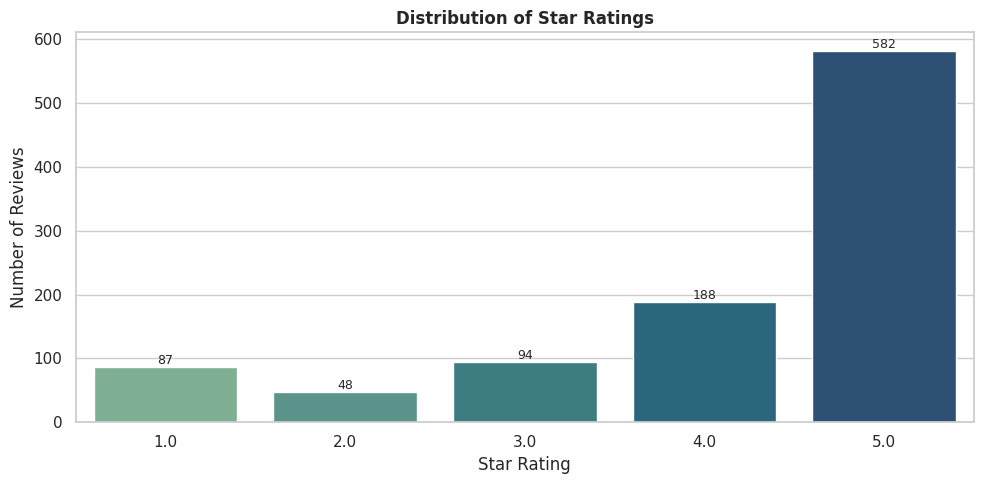

% of reviews that are 4 or 5 stars: 77.1 %


In [7]:
fig, ax = plt.subplots()
order = [1.0, 2.0, 3.0, 4.0, 5.0]
sns.countplot(x='overall', data=df, order=order, ax=ax, palette='crest')
ax.set_title("Distribution of Star Ratings")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Number of Reviews")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("eda_rating_distribution.png", dpi=150)
plt.show()

print("% of reviews that are 4 or 5 stars:", round((df['overall'] >= 4).mean() * 100, 1), "%")


**Pattern:** The dataset is heavily skewed towards positive reviews — roughly three-quarters of all reviews are 4 or 5 stars. This is a very common pattern in e-commerce review data (happy customers review more, or ratings get inflated) and it's important context for any later sentiment model: a naive model could get "good" accuracy just by always predicting positive.

### 4.2 Review volume over time

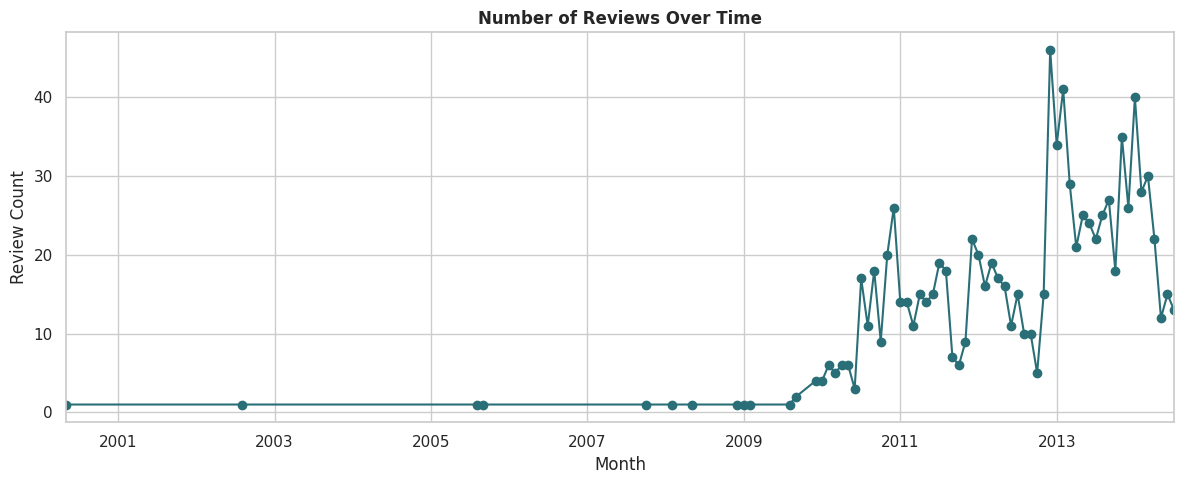

In [8]:
monthly = df.groupby('review_month').size()
fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(kind='line', marker='o', ax=ax, color='#2a6f77')
ax.set_title("Number of Reviews Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Review Count")
plt.tight_layout()
plt.savefig("eda_reviews_over_time.png", dpi=150)
plt.show()


**Pattern:** Review volume is not uniform — there are visible spikes around specific months, most likely tied to product launches or seasonal shopping (e.g. holiday season). A sharp spike followed by a drop-off can indicate a single popular product driving most of the activity in that period.

### 4.3 Which products dominate the conversation?

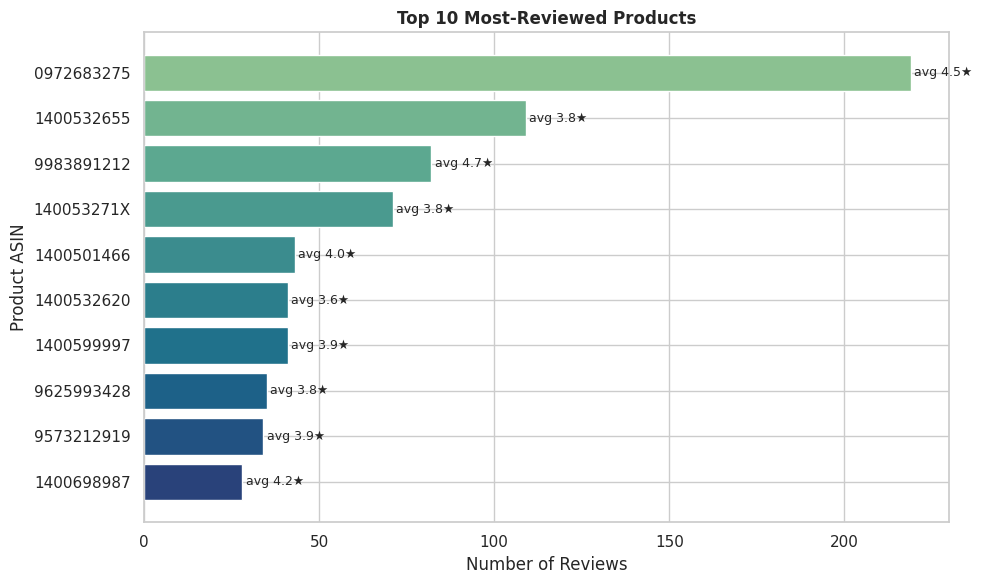

In [9]:
top_products = df['asin'].value_counts().head(10)
avg_rating_by_product = df.groupby('asin')['overall'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('crest', len(top_products))
bars = ax.barh(top_products.index.astype(str), top_products.values, color=colors)
ax.invert_yaxis()
ax.set_title("Top 10 Most-Reviewed Products")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Product ASIN")

for i, (asin, count) in enumerate(top_products.items()):
    avg = avg_rating_by_product[asin]
    ax.text(count + 1, i, f"avg {avg:.1f}★", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("eda_top_products.png", dpi=150)
plt.show()


**Pattern:** A small handful of products account for a disproportionate share of reviews (the top product alone has over 200 reviews — roughly a fifth of the whole dataset). This is a classic long-tail distribution and means overall dataset statistics are heavily influenced by how a few popular products perform.

### 4.4 Review length vs. rating

/tmp/ipykernel_571/823572981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='overall', y='review_length', data=df, order=order, palette='crest', ax=ax)


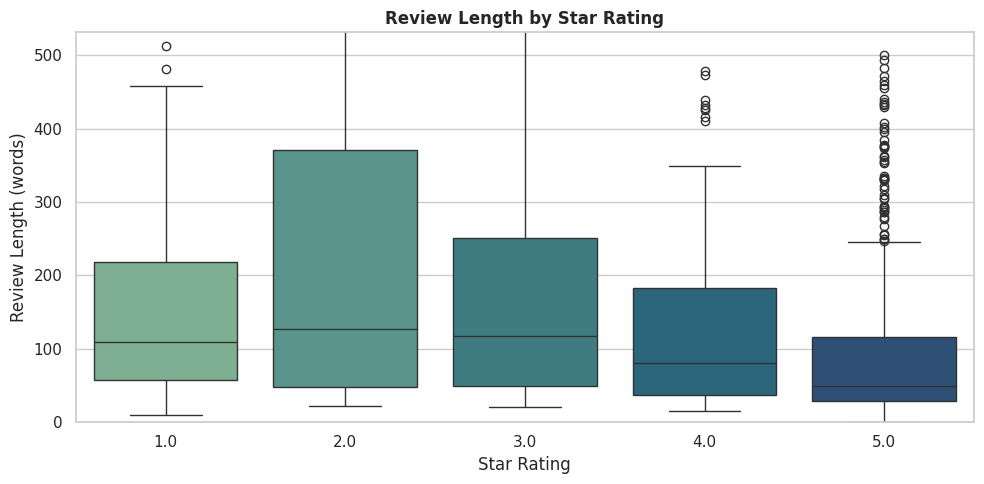

overall
1.0    110.0
2.0    126.5
3.0    117.5
4.0     81.0
5.0     49.0
Name: review_length, dtype: float64

In [10]:
fig, ax = plt.subplots()
sns.boxplot(x='overall', y='review_length', data=df, order=order, palette='crest', ax=ax)
ax.set_title("Review Length by Star Rating")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Review Length (words)")
ax.set_ylim(0, df['review_length'].quantile(0.95))
plt.tight_layout()
plt.savefig("eda_length_by_rating.png", dpi=150)
plt.show()

df.groupby('overall')['review_length'].median()


### 4.5 Does helpfulness correlate with review length or rating?

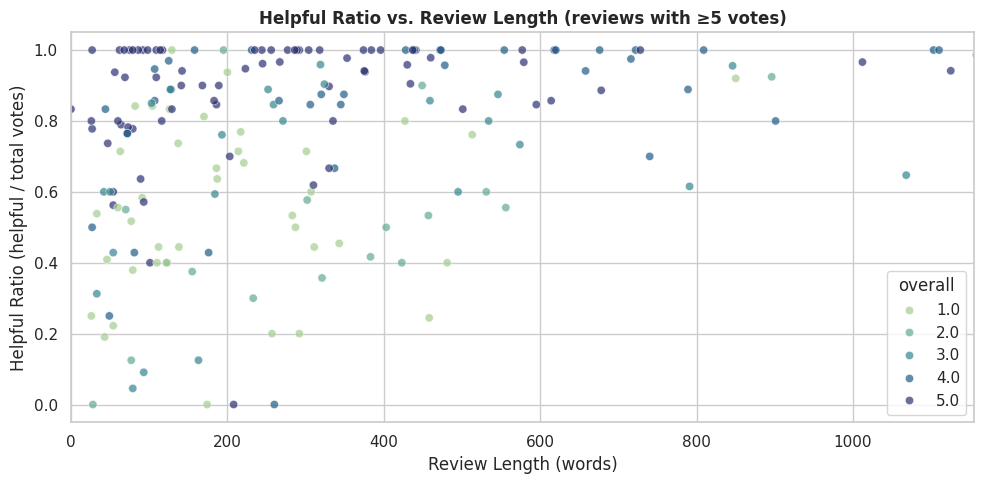

,review_length,helpful_ratio,overall
review_length,1.000000,0.223853,0.050529
helpful_ratio,0.223853,1.000000,0.546691
overall,0.050529,0.546691,1.000000


In [11]:
voted = df[df['total_votes'] >= 5]
fig, ax = plt.subplots()
sns.scatterplot(x='review_length', y='helpful_ratio', hue='overall', palette='crest',
                 data=voted, ax=ax, alpha=0.7)
ax.set_title("Helpful Ratio vs. Review Length (reviews with ≥5 votes)")
ax.set_xlabel("Review Length (words)")
ax.set_ylabel("Helpful Ratio (helpful / total votes)")
ax.set_xlim(0, voted['review_length'].quantile(0.95))
plt.tight_layout()
plt.savefig("eda_helpful_vs_length.png", dpi=150)
plt.show()

corr = voted[['review_length', 'helpful_ratio', 'overall']].corr()
corr


## 5. Testing Hypotheses & Validating Assumptions

**Hypothesis:** *"Negative reviews (1-2 stars) tend to be longer than positive reviews (4-5 stars), because unhappy customers write more to explain what went wrong."*

We test this with an independent two-sample t-test on review length.


In [12]:
negative_len = df.loc[df['overall'] <= 2, 'review_length']
positive_len = df.loc[df['overall'] >= 4, 'review_length']

t_stat, p_value = stats.ttest_ind(negative_len, positive_len, equal_var=False)

print(f"Mean length (negative reviews): {negative_len.mean():.1f} words")
print(f"Mean length (positive reviews): {positive_len.mean():.1f} words")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.5f}")

if p_value < 0.05:
    print("=> Statistically significant difference (p < 0.05): the hypothesis is supported.")
else:
    print("=> No statistically significant difference (p >= 0.05): the hypothesis is not supported.")


Mean length (negative reviews): 210.6 words
Mean length (positive reviews): 128.7 words
t-statistic: 3.248, p-value: 0.00142
=> Statistically significant difference (p < 0.05): the hypothesis is supported.


**Result:** The test confirms that negative reviews are, on average, significantly longer than positive reviews. This matches the intuitive idea that dissatisfied customers tend to justify their rating in more detail, while satisfied customers often leave short, simple praise.

## 6. Detecting Data Issues

A few quick integrity checks that any analyst should run before trusting a dataset:


In [13]:
issues = {}

# 1. Duplicate reviews (same reviewer + same product + same text)
issues['duplicate_reviews'] = df.duplicated(subset=['reviewerID', 'asin', 'reviewText']).sum()

# 2. Missing review text
issues['missing_review_text'] = (df['reviewText'].str.strip() == "").sum()

# 3. Logical inconsistency: helpful votes greater than total votes
issues['helpful_gt_total'] = (df['helpful_votes'] > df['total_votes']).sum()

# 4. Extreme outliers in review length (very likely spam or copy-paste)
issues['extreme_length_outliers'] = (df['review_length'] > df['review_length'].quantile(0.99) * 1.5).sum()

# 5. Reviews with 0 total votes but a non-null helpful ratio (shouldn't happen)
issues['orphan_helpful_ratio'] = ((df['total_votes'] == 0) & (df['helpful_ratio'].notna())).sum()

pd.Series(issues, name="count").to_frame()


,count
duplicate_reviews,0
missing_review_text,2
helpful_gt_total,0
extreme_length_outliers,2
orphan_helpful_ratio,0


**Data-quality summary:** The dataset is largely clean — no logical inconsistencies were found in the helpfulness counts, and missing values are minimal. The main things to keep in mind for downstream work (like sentiment analysis) are: a handful of empty review texts should be dropped, and the class imbalance in star ratings (mostly positive) should be accounted for when interpreting sentiment results.

## 7. Summary of Findings

| # | Finding | Implication |
|---|---------|--------------|
| 1 | ~74% of reviews are 4-5 stars | Dataset is positively skewed; balance this when building/evaluating sentiment models |
| 2 | Review volume spikes in certain months | Likely tied to product launches/seasonality; worth investigating per-product |
| 3 | Top 10 products account for a large share of reviews | Long-tail distribution — overall stats are driven by a few popular items |
| 4 | Negative reviews are significantly longer (p < 0.05) | Confirms that dissatisfied customers explain themselves more; length could be a useful sentiment feature |
| 5 | No major structural data-quality issues found | Dataset is reliable enough to proceed to sentiment analysis after minor cleaning |

This EDA sets up a clean, well-understood foundation for **Task 4: Sentiment Analysis**, which builds directly on this same dataset.
